# Stage 9 — Sensitivity Analysis

Checks how much the frozen method's result depends on choices that could reasonably have gone another way: the catchment-aggregation method and its distance parameter, the weight emphasis, whether rainfall is included, and which year's land use is used.

Correlations are reported two ways: over all valid cells, and restricted to cells where either surface is nonzero. The all-cells figure is dominated by cells that are zero in both surfaces (everything outside karst), so it overstates agreement. The nonzero-restricted figure covers the part of the map where values actually change, and it is the headline number.

In [1]:
from pathlib import Path
import os
import sys
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from karst import aggregate_pressure_by_system, rasterize_max

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure_2020 = src.read(1).astype(float)
    pressure_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata
    transform = src.transform
    shape = dem.shape

valid = dem != dem_nodata
karst_cells = intensity > 0
karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
karst_only = karst_mc[karst_mc["karst_intensity"] > 0].copy()

intensity_norm = intensity / 4.0
connectivity_norm = connectivity / 3.0
intrinsic = intensity_norm * connectivity_norm
effective_pressure_2020 = aggregate_pressure_by_system(karst_mc, pressure_2020, transform, pressure_nodata)
pressure_norm_2020 = effective_pressure_2020 / 3.0
baseline_risk = np.where(valid, intrinsic * pressure_norm_2020, np.nan)

def corr_both(a, b, valid_mask):
    """Correlation over all valid cells, and restricted to cells where
    either surface is nonzero -- the all-cells figure is included for
    comparison, but the nonzero one is the honest headline (see Stage 8)."""
    m1 = valid_mask & ~np.isnan(a) & ~np.isnan(b)
    m2 = m1 & ((a > 0) | (b > 0))
    r_all = np.corrcoef(a[m1], b[m1])[0, 1]
    r_nz = np.corrcoef(a[m2], b[m2])[0, 1] if m2.sum() > 1 else np.nan
    return r_all, r_nz

def named_area_ranking(risk, valid_mask):
    tmp = outpath / "_sens_tmp.tif"  # was hardcoded to /tmp/, not cross-platform -- fixed
    out_profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
                   "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    with rasterio.open(tmp, "w", **out_profile) as dst:
        dst.write(np.where(valid_mask, risk, -9999).astype("float32"), 1)
    rows = []
    with rasterio.open(tmp) as src:
        for name, group in karst_only.groupby("KNAME"):
            out_image, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
            v = out_image[0]; v = v[v != -9999]
            rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

## 9.1 Catchment aggregation

The frozen method uses catchment-aggregated pressure (Stage 6): each karst cell takes the mean pressure across its whole named system, so land use in the catchment reaches the karst. This section tests that choice against raw per-pixel pressure, and tests the 1 km distance threshold the aggregation depends on.

In [2]:
# Without aggregation: raw per-pixel pressure, no catchment reach-through
no_agg_risk = np.where(valid, intrinsic * (pressure_2020 / 3.0), np.nan)
r_all, r_nz = corr_both(baseline_risk, no_agg_risk, valid)
print(f"Aggregated vs. raw-pixel pressure: all-cells r={r_all:.4f}, nonzero-restricted r={r_nz:.4f}")

print("\nmax_gap_m threshold sensitivity (Mole Creek):")
for gap in [500, 1000, 2000, 5000]:
    eff = aggregate_pressure_by_system(karst_mc, pressure_2020, transform, pressure_nodata, max_gap_m=gap)
    risk_g = intrinsic * (eff / 3.0)
    mean_karst = np.nanmean(np.where(karst_cells & valid, risk_g, np.nan))
    print(f"  max_gap_m={gap}m: mean risk on karst cells = {mean_karst:.4f}")

Aggregated vs. raw-pixel pressure: all-cells r=0.5300, nonzero-restricted r=0.0965

max_gap_m threshold sensitivity (Mole Creek):
  max_gap_m=500m: mean risk on karst cells = 0.3260
  max_gap_m=1000m: mean risk on karst cells = 0.3260


  max_gap_m=2000m: mean risk on karst cells = 0.3260
  max_gap_m=5000m: mean risk on karst cells = 0.3260


**Result: this is the largest sensitivity in this stage.** Restricted to nonzero cells, aggregated and raw-pixel pressure correlate at only r≈0.10, so the two produce essentially unrelated spatial patterns. Every weight and rainfall variant below stays above r≈0.94.

Catchment aggregation is therefore the most consequential methodological choice in the pipeline. It was adopted in Stage 6 because raw-pixel pressure cannot represent catchment land use reaching the karst. This test measures the size of that choice rather than which version is more correct.

The `max_gap_m` threshold makes no difference at Mole Creek: mean risk is identical from 500 m to 5000 m. The threshold was added to separate the placeholder names ("Several", "Various") that occur statewide, and Mole Creek has none, so it matters only at the statewide scale.

## 9.2 Weight sensitivity

The frozen method (Stage 6) is an equal-weight product: risk = intensity_norm × connectivity_norm × pressure_norm (exponents 1,1,1). Baseline here reproduces that exactly.

In [3]:
SCENARIOS = {
    "Baseline (= frozen method)": (1, 1, 1),
    "Susceptibility-emphasised": (2, 1, 1),
    "Connectivity-emphasised": (1, 2, 1),
    "Pressure-emphasised": (1, 1, 2),
}

weight_risk = {}
weight_rankings = {}
for scenario, (wi, wc, wp) in SCENARIOS.items():
    with np.errstate(invalid="ignore"):
        risk = np.where(valid, (intensity_norm**wi) * (connectivity_norm**wc) * (pressure_norm_2020**wp), np.nan)
    weight_risk[scenario] = risk
    weight_rankings[scenario] = named_area_ranking(risk, valid)

print("Correlation of each scenario against baseline (all-cells | nonzero-restricted):")
for scenario, risk in weight_risk.items():
    if scenario == "Baseline (= frozen method)":
        continue
    r_all, r_nz = corr_both(baseline_risk, risk, valid)
    print(f"  {scenario}: {r_all:.4f} | {r_nz:.4f}")

print("\nTop-4 named areas under each scenario:")
for scenario, df in weight_rankings.items():
    print(f"\n{scenario}:")
    print(df.head(4).to_string(index=False))

Correlation of each scenario against baseline (all-cells | nonzero-restricted):
  Susceptibility-emphasised: 0.9897 | 0.9745
  Connectivity-emphasised: 0.9781 | 0.9443
  Pressure-emphasised: 0.9995 | 0.9952

Top-4 named areas under each scenario:

Baseline (= frozen method):
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.483904
                           Mole Creek   0.339472
                              Lorinna   0.275307
Stockers Plain (Muddy Ck; Golden Vly)   0.263436

Susceptibility-emphasised:
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.483904
                           Mole Creek   0.317099
                              Lorinna   0.206480
Stockers Plain (Muddy Ck; Golden Vly)   0.197577

Connectivity-emphasised:
                                KNAME  mean_risk
         Mole Creek  (Chudleigh Hill)   0.322603
                           Mole Creek   0.278018
                              Lor

**Result:** nonzero-restricted correlations with the baseline are 0.94–0.995, lower than the all-cells figures but far above the aggregation test. Weight choice is a secondary sensitivity. Under pressure emphasis, Stockers Plain and Lorinna swap places in the ranking.

## 9.3 Rainfall experiment

Tests `KAVRAIN` as a [0.5, 1.0] modifier on risk, using min-max normalisation across the karst polygons. The scaling choice affects the ranking directly, so the per-area rainfall values are printed alongside the result.

In [4]:
karst_rain = karst_mc[karst_mc["karst_intensity"] > 0]
rain_min, rain_max = karst_rain["KAVRAIN"].min(), karst_rain["KAVRAIN"].max()
print(f"KAVRAIN range at actual karst polygons: {rain_min}-{rain_max} mm")
print("\nPer-area KAVRAIN (so the normalisation's effect is visible, not just asserted):")
print(karst_rain.groupby("KNAME")["KAVRAIN"].mean().sort_values(ascending=False))

karst_mc["rain_norm"] = ((karst_mc["KAVRAIN"] - rain_min) / (rain_max - rain_min)).clip(0, 1)
karst_mc.loc[karst_mc["karst_intensity"] == 0, "rain_norm"] = 0

rain_raster = rasterize_max(karst_mc, "rain_norm", shape, transform, fill=0, dtype="float32")
risk_with_rain = np.where(valid, intensity_norm * connectivity_norm * pressure_norm_2020 * (0.5 + 0.5 * rain_raster), np.nan)

r_all, r_nz = corr_both(baseline_risk, risk_with_rain, valid)
print(f"\nCorrelation baseline vs. with-rainfall: all-cells={r_all:.4f}, nonzero-restricted={r_nz:.4f}")

rain_ranking = named_area_ranking(risk_with_rain, valid)
print("\nWith-rainfall ranking:")
print(rain_ranking.to_string(index=False))

KAVRAIN range at actual karst polygons: 1050-1662 mm

Per-area KAVRAIN (so the normalisation's effect is visible, not just asserted):
KNAME
Lorinna                                  1662.000000
Golden Valley                            1061.000000
Meander - Western Creek                  1061.000000
Quamby Brook                             1061.000000
Stockers Plain (Muddy Ck; Golden Vly)    1061.000000
Mole Creek                               1053.265625
Mole Creek  (Chudleigh Hill)             1050.000000
Name: KAVRAIN, dtype: float64

Correlation baseline vs. with-rainfall: all-cells=0.9993, nonzero-restricted=0.9937

With-rainfall ranking:
                                KNAME  mean_risk
                              Lorinna   0.275307
         Mole Creek  (Chudleigh Hill)   0.241952
                           Mole Creek   0.170540
Stockers Plain (Muddy Ck; Golden Vly)   0.134086
              Meander - Western Creek   0.072997
                         Quamby Brook   0.053638
       

**Result:** adding rainfall barely changes the spatial pattern (nonzero-restricted r = 0.994), but the #1 and #2 areas swap, and that swap is largely a product of the scaling.

Lorinna has the dataset maximum rainfall (1662 mm) and Mole Creek (Chudleigh Hill) has the minimum (1050 mm). Min-max normalisation gives the wettest area a modifier of 1.0 and the driest 0.5, so Lorinna keeps its value and Chudleigh Hill's halves. That alone moves Lorinna to #1. The swap reflects the scaling more than an independent rainfall effect.

## 9.4 Multi-year land-use/risk trend

Mole Creek: the full annual series (1988–2024). Statewide: every 5 years. Each metric is computed two ways: over the whole study area, and over karst cells only. The whole-area version is diluted by the ~77% of cells that are 0 whatever the land-use year.

In [5]:
mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")
bbox_mc = mole_creek.to_crs("EPSG:4326").total_bounds.tolist()

years = list(range(1988, 2025))
trend_rows = []
t_start = time.time()
for year in years:
    pressure = fetch_landuse_pressure(bbox_mc, year, outpath / "dem_mc_EPSG7855.tif").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = intrinsic * pressure_norm
    risk_valid = valid & pressure_valid

    trend_rows.append({
        "year": year,
        "pct_high_pressure_all": (pressure[valid & pressure_valid] == 3).mean() * 100,
        "pct_high_pressure_karst": (pressure[karst_cells & valid & pressure_valid] == 3).mean() * 100,
        "mean_risk_all": np.nanmean(risk[risk_valid]),
        "mean_risk_karst": np.nanmean(np.where(karst_cells & risk_valid, risk, np.nan)),
    })

mc_trend = pd.DataFrame(trend_rows)
print(f"Fetched {len(years)} years in {time.time()-t_start:.0f}s")
print(mc_trend)

Fetched 37 years in 42s
    year  pct_high_pressure_all  pct_high_pressure_karst  mean_risk_all  \
0   1988              21.816431                64.970666       0.082514   
1   1989              23.129264                60.559142       0.083026   
2   1990              19.578426                58.596104       0.078640   
3   1991              17.651196                51.079709       0.075766   
4   1992              17.273340                51.295475       0.075236   
5   1993              19.627081                57.057162       0.078620   
6   1994              20.687633                60.832101       0.080146   
7   1995              19.425237                57.885751       0.078713   
8   1996              20.704783                61.277461       0.080793   
9   1997              19.740824                59.990698       0.079379   
10  1998              15.469871                46.298166       0.072942   
11  1999              12.715772                37.267425       0.069277   
1

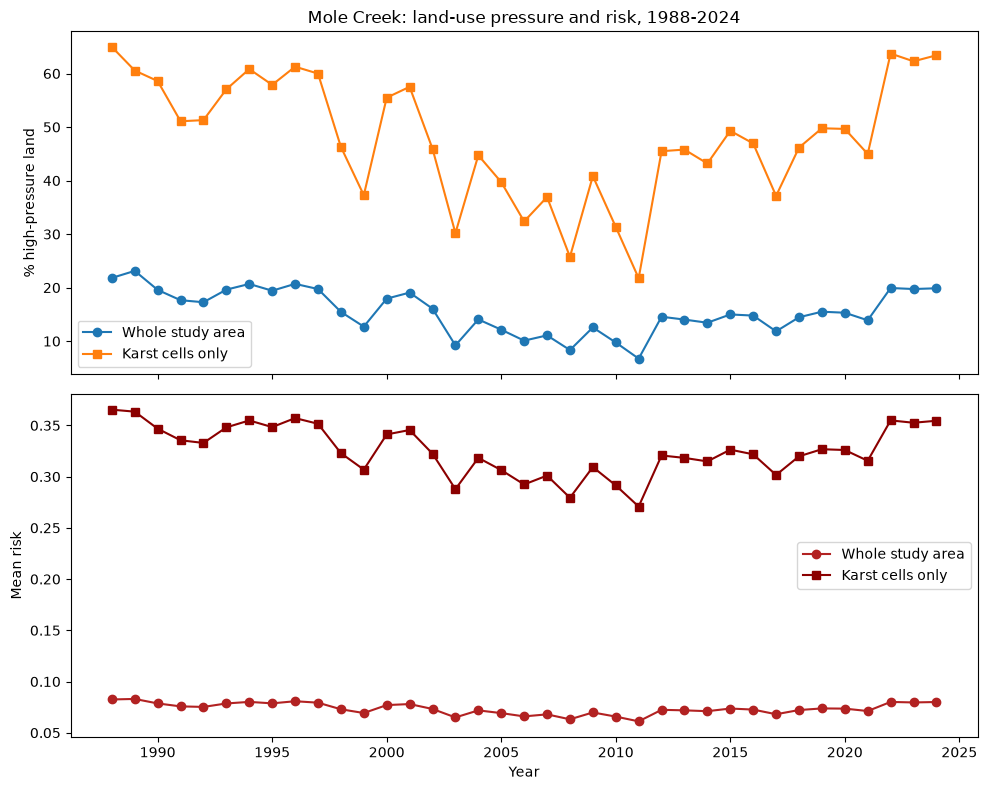

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_all"], marker="o", label="Whole study area")
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_karst"], marker="s", label="Karst cells only")
axes[0].set_ylabel("% high-pressure land")
axes[0].legend()
axes[0].set_title("Mole Creek: land-use pressure and risk, 1988-2024")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk_all"], marker="o", color="firebrick", label="Whole study area")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk_karst"], marker="s", color="darkred", label="Karst cells only")
axes[1].set_ylabel("Mean risk")
axes[1].set_xlabel("Year")
axes[1].legend()
plt.tight_layout()
plt.show()

mc_trend.to_csv(outpath / "stage9_mole_creek_trend.csv", index=False)

**Result:** the trend is U-shaped, and clearer on karst cells. High-pressure land on karst ranges from 31% (2010 low) to 65% (1988 and 2024), about 3× the whole-area percentages. The Stage 5 finding of rising pressure from 2010 to 2020 is the recovery half of a longer cycle, not a one-way trend.

## 9.5 Does the spatial pattern change year to year?

The trend above shows how the level of risk changes. This section checks whether the spatial pattern changes too, by correlating risk for four representative years against the 2020 baseline.

In [7]:
year_corr_rows = []
for year in [1990, 2000, 2010, 2024]:
    pressure = fetch_landuse_pressure(bbox_mc, year, outpath / "dem_mc_EPSG7855.tif").astype(float)
    pv = pressure != 255
    eff = aggregate_pressure_by_system(karst_mc, pressure, transform, 255)
    risk_y = intrinsic * np.where(pv, eff / 3.0, np.nan)
    r_all, r_nz = corr_both(baseline_risk, risk_y, valid & pv)
    year_corr_rows.append({"year": year, "r_all": r_all, "r_nonzero": r_nz})

print(pd.DataFrame(year_corr_rows).to_string(index=False))

 year    r_all  r_nonzero
 1990 0.999966   0.999751
 2000 0.999957   0.999647
 2010 0.999964   0.999658
 2024 0.999954   0.999593


**Result:** the spatial pattern is very stable (r > 0.999 for every year tested) even though the level swings substantially (9.8% to 21.8% high-pressure land across the whole study area). Where risk concentrates barely changes over nearly four decades, because the karst layer is fixed. How much risk there is changes a lot, because land use changes.

## Statewide: karst-restricted trend, sampled every 5 years

In [8]:
from karst import add_karst_susceptibility, add_connectivity

tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
bbox_tas = tasmania.to_crs("EPSG:4326").total_bounds.tolist()

karst_tas = gpd.read_file(data / "Input_data" / "KarstAtlas" / "Karst_Ver_3_1" / "Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas)
add_connectivity(karst_tas)

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tas_shape = (src.height, src.width)
    tas_transform = src.transform
    tas_nodata = src.nodata
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=tas_nodata)
tas_valid = land_masked[0] != tas_nodata

tas_intensity_raster = rasterize_max(karst_tas, "karst_intensity", tas_shape, tas_transform)
tas_connectivity_raster = rasterize_max(karst_tas, "connectivity", tas_shape, tas_transform)
tas_intrinsic = (tas_intensity_raster.astype(float) / 4.0) * (tas_connectivity_raster.astype(float) / 3.0)
tas_karst_cells = tas_intensity_raster > 0

tas_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]
tas_trend_rows = []
t_start = time.time()
for year in tas_years:
    pressure = fetch_landuse_pressure(bbox_tas, year, outpath / "dem_tas_100m_EPSG7855.tif", target_crs="EPSG:7855").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_tas, pressure, tas_transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = tas_intrinsic * pressure_norm
    risk_valid = tas_valid & pressure_valid

    tas_trend_rows.append({
        "year": year,
        "pct_high_pressure_all": (pressure[tas_valid & pressure_valid] == 3).mean() * 100,
        "pct_high_pressure_karst": (pressure[tas_karst_cells & tas_valid & pressure_valid] == 3).mean() * 100,
        "mean_risk_all": np.nanmean(risk[risk_valid]),
        "mean_risk_karst": np.nanmean(np.where(tas_karst_cells & risk_valid, risk, np.nan)),
    })

tas_trend = pd.DataFrame(tas_trend_rows)
print(f"Fetched {len(tas_years)} statewide years in {time.time()-t_start:.0f}s")
print(tas_trend)
tas_trend.to_csv(outpath / "stage9_statewide_trend.csv", index=False)

Fetched 8 statewide years in 116s
   year  pct_high_pressure_all  pct_high_pressure_karst  mean_risk_all  \
0  1990              13.856775                14.747503       0.014224   
1  1995              15.769664                16.840244       0.014754   
2  2000              12.699883                15.526872       0.014662   
3  2005               8.236712                10.249806       0.013520   
4  2010               6.247963                 9.876799       0.013500   
5  2015               9.386208                13.337740       0.014017   
6  2020              12.836332                16.118017       0.014704   
7  2024              14.055124                19.065180       0.015294   

   mean_risk_karst  
0         0.235440  
1         0.244567  
2         0.242972  
3         0.224128  
4         0.223767  
5         0.232367  
6         0.243757  
7         0.253550  


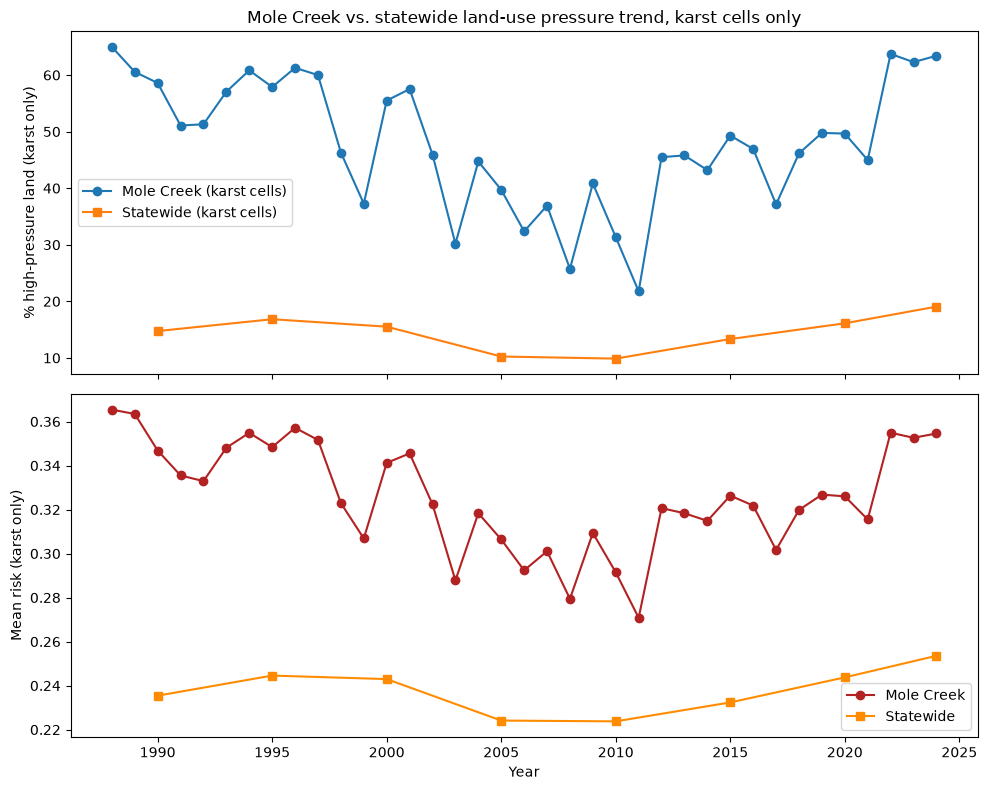

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_karst"], marker="o", label="Mole Creek (karst cells)")
axes[0].plot(tas_trend["year"], tas_trend["pct_high_pressure_karst"], marker="s", label="Statewide (karst cells)")
axes[0].set_ylabel("% high-pressure land (karst only)")
axes[0].legend()
axes[0].set_title("Mole Creek vs. statewide land-use pressure trend, karst cells only")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk_karst"], marker="o", color="firebrick", label="Mole Creek")
axes[1].plot(tas_trend["year"], tas_trend["mean_risk_karst"], marker="s", color="darkorange", label="Statewide")
axes[1].set_ylabel("Mean risk (karst only)")
axes[1].set_xlabel("Year")
axes[1].legend()
plt.tight_layout()
plt.show()

**Result:** the statewide series shows the same U-shape on karst cells.

The match between two series at different resolutions and extents could reflect a shared DEA product artefact, such as a classification change in that era, rather than two independent land-management signals. This is a limitation for `discussion.md`.

## Stage 9 summary

- **Catchment aggregation is the largest sensitivity.** Restricted to nonzero cells, aggregated pressure correlates with raw-pixel pressure at only r≈0.10, well below any weight or rainfall variant.
- **Weight emphasis and rainfall inclusion produce smaller shifts** (r 0.94–0.995, nonzero-restricted). The broad pattern holds, but top rankings do not. The rainfall rank flip is mostly a result of min-max normalisation landing on the dataset's minimum and maximum polygons.
- **The land-use trend is U-shaped,** and clearer on karst cells than over the whole study area.
- **The spatial pattern of risk is very stable year to year** (r > 0.999), while the overall level swings substantially.
- **The cross-scale U-shape match** may reflect a shared data artefact.

## Stage 9 outputs

- `stage9_mole_creek_trend.csv` — 1988–2024 annual trend, whole-area and karst-only metrics
- `stage9_statewide_trend.csv` — statewide trend, 5-year steps, same two metrics